In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('shop_smart_ecommerce.csv')

In [3]:
X = df.drop(columns = ['Revenue'])
y = df['Revenue'].astype(int)

# Splitting the data into Numerical and Categorical type

In [4]:
num_features = X.select_dtypes(include = ['int64', 'float64']).columns
cat_features = X.select_dtypes(include = ['object', 'category']).columns

# Train Test Split

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing Pipeline

In [6]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_features)
    ]
)

In [7]:
dt = DecisionTreeClassifier(
    max_depth=6,              # prevents deep overfitting
    min_samples_leaf=30,      # smooths decision boundaries
    class_weight="balanced",  # handles imbalance
    random_state=42
)

In [8]:
pipe = Pipeline(
    steps= [
        ('preprocess', preprocessor),
        ('model', dt)
    ]
)

# Training the Pipeline

In [9]:
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
y_pred = pipe.predict(X_test)

print('F1 score:', f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.6278381046396841

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      2084
           1       0.50      0.83      0.63       382

    accuracy                           0.85      2466
   macro avg       0.73      0.84      0.77      2466
weighted avg       0.89      0.85      0.86      2466


Confusion Matrix:
 [[1771  313]
 [  64  318]]


# Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [4, 6, 8],
    "model__min_samples_leaf": [20, 30, 50]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring = 'f1',
    cv= 5,
    n_jobs = -1
)

grid.fit(X_train, y_train)

print("Best F1:", grid.best_score_)
print("Best params:", grid.best_params_)

Best F1: 0.6343735129725652
Best params: {'model__max_depth': 4, 'model__min_samples_leaf': 50}


# Visualizing the Decision Tree Model

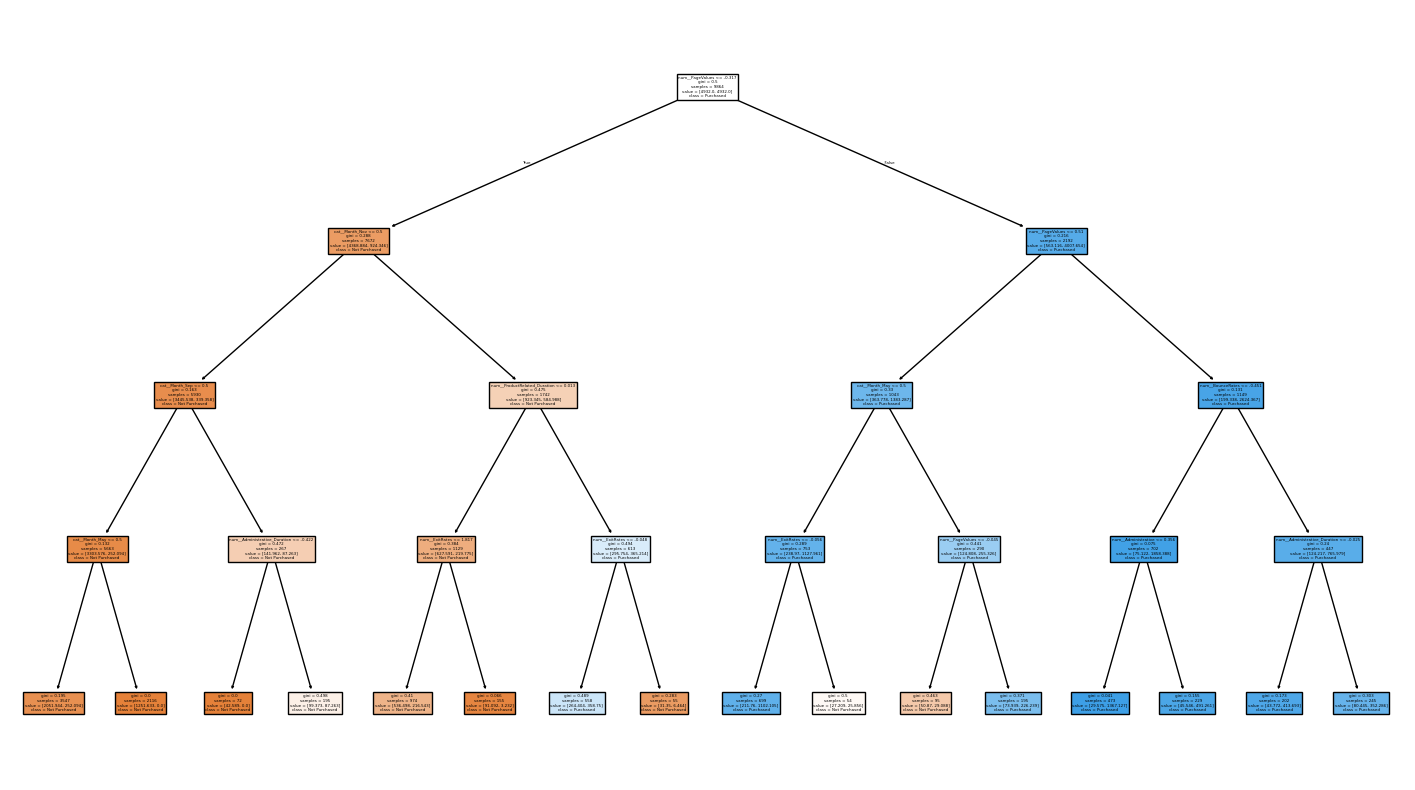

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    grid.best_estimator_['model'], 
    feature_names=grid.best_estimator_['preprocess'].get_feature_names_out(),
    class_names=['Not Purchased', 'Purchased'], 
    filled=True
)
plt.show()